# Clusterizador com Local Outlier Factor

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import LocalOutlierFactor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import optuna

## Ler Dados

In [36]:
df_stars = pd.read_csv("./dataset/pulsar.csv")
df_stars.info()

<class 'pandas.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Mean of the integrated profile                17898 non-null  float64
 1   Standard deviation of the integrated profile  17898 non-null  float64
 2   Excess kurtosis of the integrated profile     17898 non-null  float64
 3   Skewness of the integrated profile            17898 non-null  float64
 4   Mean of the DM-SNR curve                      17898 non-null  float64
 5   Standard deviation of the DM-SNR curve        17898 non-null  float64
 6   Excess kurtosis of the DM-SNR curve           17898 non-null  float64
 7   Skewness of the DM-SNR curve                  17898 non-null  float64
 8   target_class                                  17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [37]:
df_stars.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


## Distribuição da Variável Target

In [38]:
df_stars.value_counts('target_class', normalize=True) * 100 # type: ignore

target_class
0    90.842552
1     9.157448
Name: proportion, dtype: float64

## Tratar Dados

In [39]:
X = df_stars.drop(columns=['target_class'])
y = df_stars['target_class']

colunas_numericas = X.columns.tolist()

preprocessor = ColumnTransformer(transformers=[
  ('num', StandardScaler(), colunas_numericas)
])

X_transformed = preprocessor.fit_transform(X)

## Função de Tuning

In [40]:
def lof_objective(trial: optuna.Trial):
    metric = trial.suggest_categorical('metric', ['chebyshev', 'cityblock', 'euclidean'])
    contamination = trial.suggest_float('contamination', low=0.09, high=0.1)
    neighbours = trial.suggest_int('neighbours', low=1100, high=1600)
    algorithm = trial.suggest_categorical('algorithm', ['ball_tree', 'kd_tree', 'brute'])

    model_opt = LocalOutlierFactor(
      metric=metric,
      contamination=contamination,
      n_neighbors=neighbours,
      algorithm=algorithm, # type: ignore
      n_jobs=-1,
    )

    opt_pred = model_opt.fit_predict(X_transformed)

    opt_pred = [1 if item == -1 else 0 for item in opt_pred]

    return f1_score(y_pred=opt_pred, y_true=y, average='binary', pos_label=1)

## Criar estudo

In [41]:
search_space = {
  'metric': ['chebyshev', 'cityblock', 'euclidean'],
  'contamination': [0.09, 0.1],
  'neighbours': list(range(1100, 1600+1, 100)),
  'algorithm': ['ball_tree', 'kd_tree', 'brute'],
}
sampler = optuna.samplers.GridSampler(
  search_space=search_space,
  seed=51,
)
lof_study = optuna.create_study(
  direction='maximize',
  sampler=sampler,
  study_name='LOF Study',
)
lof_study.optimize(
  gc_after_trial=True,
  func=lof_objective, # type: ignore
  n_jobs=-1,
  show_progress_bar=True,
  n_trials=
    (len(search_space['algorithm']) *
     len(search_space['contamination']) *
     len(search_space['metric']) *
     len(search_space['neighbours']))
)

[I 2026-08-02 18:47:03,420] A new study created in memory with name: LOF Study


  0%|          | 0/108 [00:00<?, ?it/s]

[I 2026-08-02 18:47:50,036] Trial 4 finished with value: 0.5384615384615384 and parameters: {'metric': 'euclidean', 'contamination': 0.09, 'neighbours': 1500, 'algorithm': 'brute'}. Best is trial 4 with value: 0.5384615384615384.
[I 2026-08-02 18:47:50,709] Trial 7 finished with value: 0.5406824146981627 and parameters: {'metric': 'euclidean', 'contamination': 0.1, 'neighbours': 1400, 'algorithm': 'brute'}. Best is trial 7 with value: 0.5406824146981627.
[I 2026-08-02 18:47:51,175] Trial 2 finished with value: 0.5010207057451151 and parameters: {'metric': 'euclidean', 'contamination': 0.1, 'neighbours': 1300, 'algorithm': 'brute'}. Best is trial 7 with value: 0.5406824146981627.
[I 2026-08-02 18:47:52,484] Trial 3 finished with value: 0.558180227471566 and parameters: {'metric': 'euclidean', 'contamination': 0.1, 'neighbours': 1500, 'algorithm': 'brute'}. Best is trial 3 with value: 0.558180227471566.
[I 2026-08-02 18:47:53,510] Trial 0 finished with value: 0.46092307692307694 and para

### Melhores parâmetros

In [53]:
lof_study.best_params

{'metric': 'chebyshev',
 'contamination': 0.1,
 'neighbours': 1500,
 'algorithm': 'kd_tree'}

### Melhor f1-score

In [54]:
lof_study.best_value

0.621172353455818

## Treinar modelo com melhores parâmetros

In [55]:
best_params = lof_study.best_params

In [56]:
model_lof = LocalOutlierFactor(
  n_neighbors=best_params['neighbours'],
  contamination=best_params['contamination'],
  metric=best_params['metric'],
  algorithm=best_params['algorithm'],
  n_jobs=-1,
)

In [57]:
y_pred = model_lof.fit_predict(X_transformed)

In [58]:
y_pred[:20]

array([ 1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1])

## Métricas

### Adequar y_pred para a variável target

In [59]:
y_pred = [1 if item == -1 else 0 for item in y_pred]

In [60]:
df_stars['cluster'] = y_pred

### Classification Report

In [62]:
table = classification_report(df_stars['target_class'], df_stars['cluster'])
print(table)

              precision    recall  f1-score   support

           0       0.96      0.96      0.96     16259
           1       0.59      0.65      0.62      1639

    accuracy                           0.93     17898
   macro avg       0.78      0.80      0.79     17898
weighted avg       0.93      0.93      0.93     17898



### Matriz de Confusão

In [63]:
conf_matrix = confusion_matrix(df_stars['target_class'], df_stars['cluster'])

Text(0.5, 1.0, 'Confusion Matrix')

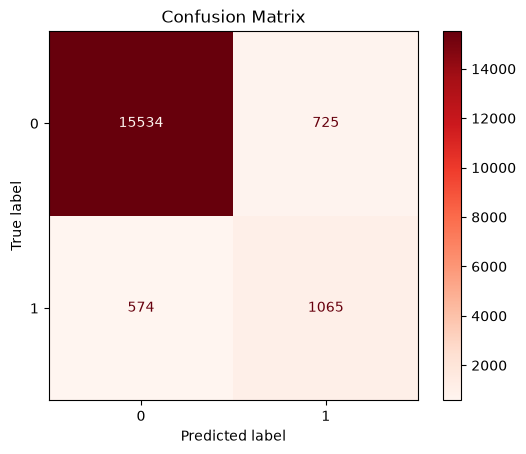

In [65]:
cmd = ConfusionMatrixDisplay(conf_matrix)
cmd.plot(
  cmap='Reds',
)
plt.title("Confusion Matrix")